In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview

import matplotlib
from matplotlib import pyplot as plt
from IPython.display import display

import sys
sys.path.insert(0,'../code')
import maps

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18

matplotlib.rc('text', usetex=False)

In [3]:
cmap_map = 'plasma'
NSIDE = 64

## Zodi templates

In [4]:
zodi_names = ['zodi1.25', 'zodi3.4', 'zodi4.6']
maps_zodi = {}
for name in zodi_names:
    fn_map = maps.template_map_fn(name, NSIDE)
    maps_zodi[name] = maps.get_zodi_map(NSIDE=NSIDE, fn_map=fn_map)
    m = maps_zodi[name]
    print(name, fn_map)
    print(m.shape, np.nanmin(m), np.nanmax(m))

Zodi map already exists, loading from ../data/selection_function_template_maps/map_zodi1.25_NSIDE64.npy
zodi1.25 ../data/selection_function_template_maps/map_zodi1.25_NSIDE64.npy
(49152,) 0.10684949405964762 0.4849161883946152
Zodi map already exists, loading from ../data/selection_function_template_maps/map_zodi3.4_NSIDE64.npy
zodi3.4 ../data/selection_function_template_maps/map_zodi3.4_NSIDE64.npy
(49152,) 0.048103230068038516 0.1404315346571656
Zodi map already exists, loading from ../data/selection_function_template_maps/map_zodi4.6_NSIDE64.npy
zodi4.6 ../data/selection_function_template_maps/map_zodi4.6_NSIDE64.npy
(49152,) 0.24975327253049867 0.5716788734290856


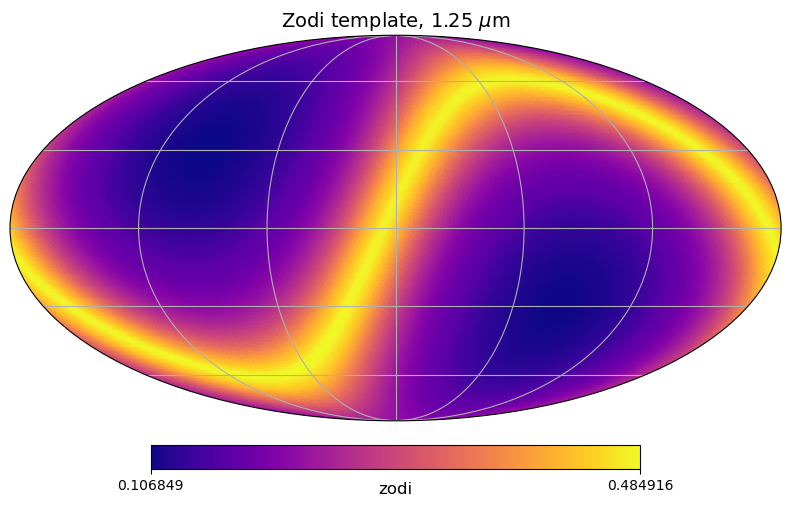

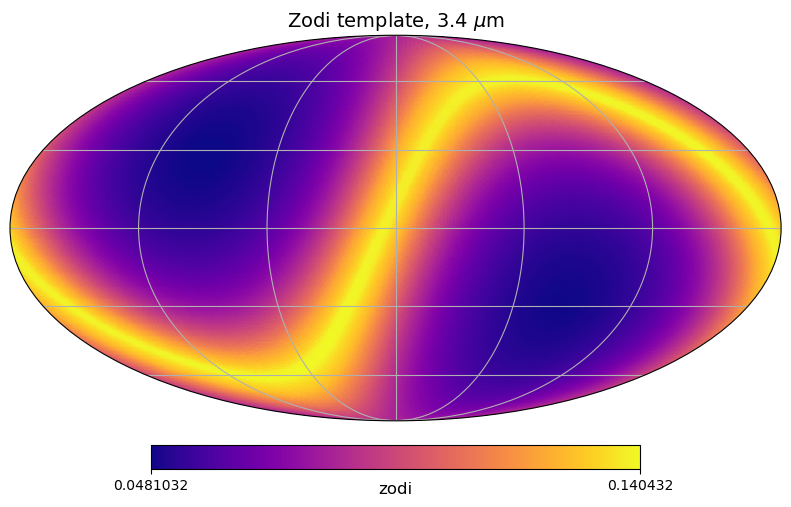

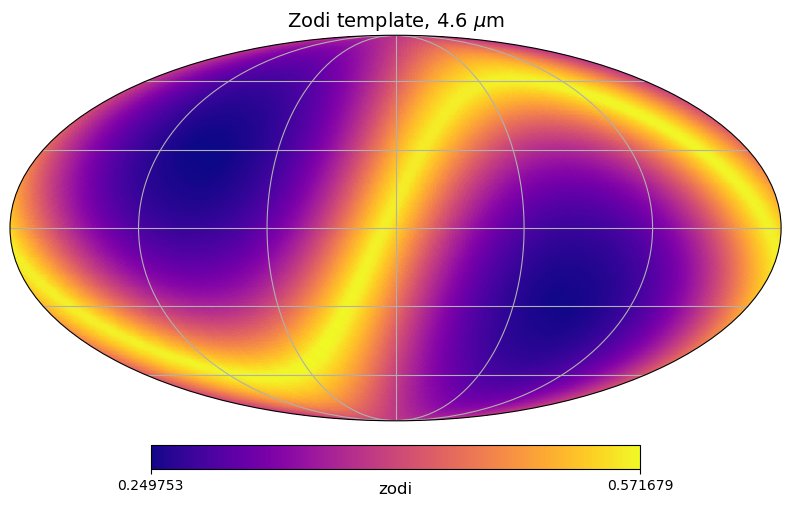

In [5]:
zodi_titles = {
    'zodi1.25': r'Zodi template, 1.25 $\mu$m',
    'zodi3.4': r'Zodi template, 3.4 $\mu$m',
    'zodi4.6': r'Zodi template, 4.6 $\mu$m',
}
for name, m in maps_zodi.items():
    projview(m, title=zodi_titles[name],
             unit='zodi', cmap=cmap_map, coord=['C', 'G'],
             graticule=True,
             min=np.nanmin(m), max=np.nanmax(m),
            )
    display(plt.gcf())
    plt.close()

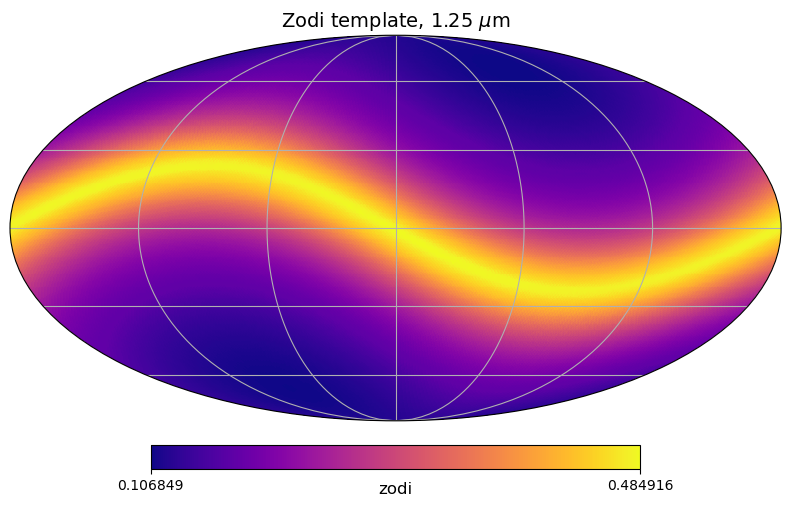

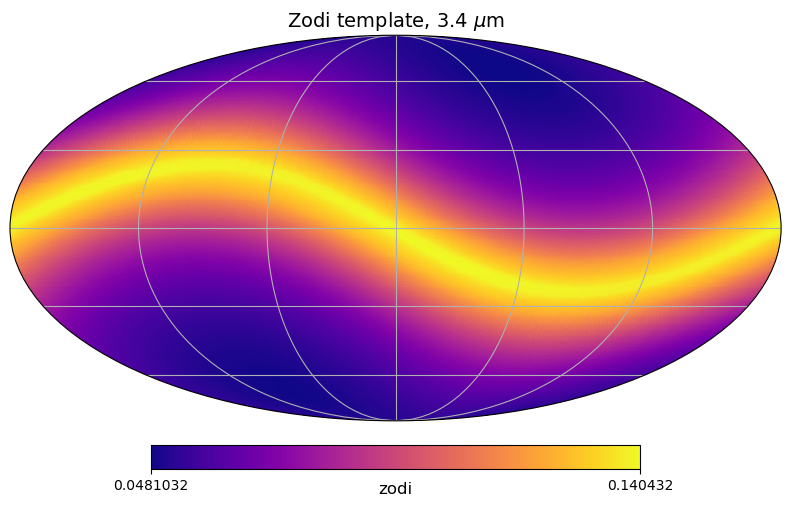

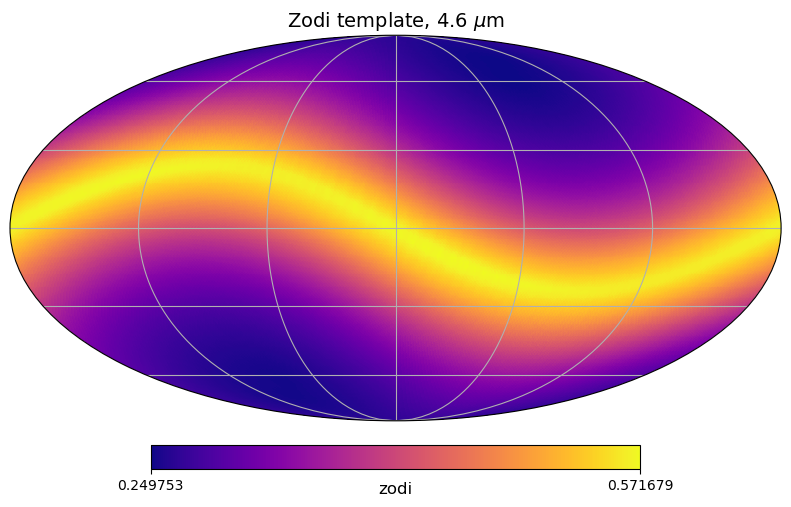

In [6]:
for name, m in maps_zodi.items():
    projview(m, title=zodi_titles[name],
             unit='zodi', cmap=cmap_map, coord=['C'],
             graticule=True,
             min=np.nanmin(m), max=np.nanmax(m),
            )
    display(plt.gcf())
    plt.close()

## Selfunc

In [8]:
tag_selfunc = '_pluszodisnew'
fn_selfunc = f'../data/maps/selection_function_NSIDE{NSIDE}_G20.0{tag_selfunc}.fits'
map_selfunc = hp.read_map(fn_selfunc)
print(fn_selfunc)
print(map_selfunc.shape)

../data/maps/selection_function_NSIDE64_G20.0_pluszodisnew.fits
(49152,)


In [9]:
np.min(map_selfunc), np.min(map_selfunc[map_selfunc>0]), np.max(map_selfunc)

(np.float64(0.0),
 np.float64(0.024289920051195193),
 np.float64(0.7770501617705053))

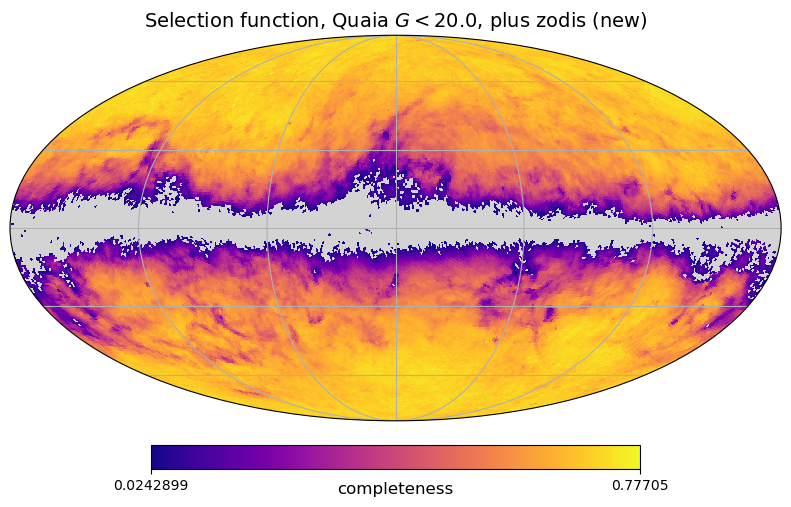

In [11]:
map_selfunc_plot = map_selfunc.astype(float).copy()
map_selfunc_plot[map_selfunc_plot<=0] = np.nan
projview(map_selfunc_plot, title=r'Selection function, Quaia $G<20.0$, plus zodis (new)',
         unit='completeness', cmap=cmap_map, coord=['C', 'G'],
         graticule=True, badcolor='lightgray',
         min=np.min(map_selfunc[map_selfunc>0]), max=np.max(map_selfunc),
        )
display(plt.gcf())
plt.close()